# Machine Learning for Thermal Engineers
## Lesson 5: Feature Engineering

Author: Srikantan Natarajan

# 1. Motivation

In previous lessons we used raw input variables such as:

- Ambient temperature
- Solar load
- Cabin temperature
- Set temperature
- Humidity
- Blower speed

However, raw variables are not always the most informative inputs.

Often we can create **derived variables that better represent the physics of the system**.

This process is called **feature engineering**.

In this lesson we will compare:

Model A: raw features  
Model B: engineered features

# 2. Mathematical Intuition

Suppose we want to predict compressor power.

A model using raw features might look like:

$$
y = w_1(\mathrm{AmbientTemp}) + w_2(\mathrm{SolarLoad}) + w_3(\mathrm{Humidity}) + w_4(\mathrm{CabinTemp}) + w_5(\mathrm{SetTemp}) + w_6(\mathrm{BlowerSpeed}) + b
$$

But from an engineering perspective, the true cooling demand is often driven more directly by **temperature error** than by cabin temperature and set temperature separately.

So we can define an engineered feature:

$$
\mathrm{TempError} = T_{cabin} - T_{set}
$$

This new feature directly captures how far the cabin is from the target temperature.

The idea of feature engineering is to give the model variables that are **closer to the real physics of the problem**.

# 3. Engineering Analogy

Thermal engineers already use engineered variables all the time.

Examples include:

- Cabin error
- Teq error
- Duct temperature error
- Temperature deltas
- Equivalent temperature terms

These are often more useful than raw sensor values because they better represent the state of the system.

Machine learning benefits from the same idea.

Instead of asking the model to discover all useful relationships from raw variables alone, we can guide it by creating physically meaningful features.

# 4. Create a Synthetic HVAC Dataset

To keep this notebook self-contained and non-proprietary, we will generate a synthetic HVAC-style dataset.

The dataset will include:

- Ambient temperature
- Solar load
- Humidity
- Cabin temperature
- Set temperature
- Blower speed

We will then compare a model built with raw features against a model built with engineered features.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

np.random.seed(42)

n_samples = 200

ambient_temp = np.random.uniform(25, 45, n_samples)      # deg C
solar_load = np.random.uniform(200, 1000, n_samples)     # W/m^2
humidity = np.random.uniform(30, 80, n_samples)          # %
cabin_temp = np.random.uniform(22, 45, n_samples)        # deg C
set_temp = np.random.uniform(18, 24, n_samples)          # deg C
blower_speed = np.random.uniform(5, 10, n_samples)       # arbitrary scale

noise = np.random.normal(0, 0.25, n_samples)

compressor_power = (
    0.05 * ambient_temp +
    0.0015 * solar_load +
    0.015 * humidity +
    0.12 * cabin_temp -
    0.10 * set_temp +
    0.08 * blower_speed +
    noise
)

df = pd.DataFrame({
    "AmbientTemp_C": ambient_temp,
    "SolarLoad_Wm2": solar_load,
    "Humidity_pct": humidity,
    "CabinTemp_C": cabin_temp,
    "SetTemp_C": set_temp,
    "BlowerSpeed": blower_speed,
    "CompressorPower_kW": compressor_power
})

df.head()

,AmbientTemp_C,SolarLoad_Wm2,Humidity_pct,CabinTemp_C,SetTemp_C,BlowerSpeed,CompressorPower_kW
0,32.490802,713.625317,35.156193,25.885506,22.243432,5.925665,4.969673
1,44.014286,267.311972,75.127645,28.407578,18.915234,7.709505,5.846306
2,39.639879,329.302971,55.262619,26.071241,21.457730,9.364729,4.898042
3,36.973170,918.843351,71.322873,24.040158,21.640290,8.661124,6.180736
4,28.120373,685.143248,46.002480,24.774625,20.544784,9.032806,4.402868


# 5. Create Engineered Features

Now we create a few derived variables.

The most important one is:

$$
\mathrm{TempError} = T_{cabin} - T_{set}
$$

This feature directly represents cooling demand.

We also scale solar load and humidity so that their numerical magnitudes are easier to interpret.

In [3]:
df["TempError"] = df["CabinTemp_C"] - df["SetTemp_C"]
df["SolarScaled"] = df["SolarLoad_Wm2"] / 1000
df["HumidityScaled"] = df["Humidity_pct"] / 100

df.head()

,AmbientTemp_C,SolarLoad_Wm2,Humidity_pct,CabinTemp_C,SetTemp_C,BlowerSpeed,CompressorPower_kW,TempError,SolarScaled,HumidityScaled
0,32.490802,713.625317,35.156193,25.885506,22.243432,5.925665,4.969673,3.642075,0.713625,0.351562
1,44.014286,267.311972,75.127645,28.407578,18.915234,7.709505,5.846306,9.492344,0.267312,0.751276
2,39.639879,329.302971,55.262619,26.071241,21.457730,9.364729,4.898042,4.613511,0.329303,0.552626
3,36.973170,918.843351,71.322873,24.040158,21.640290,8.661124,6.180736,2.399868,0.918843,0.713229
4,28.120373,685.143248,46.002480,24.774625,20.544784,9.032806,4.402868,4.229841,0.685143,0.460025


# 6. Model A: Linear Regression Using Raw Features

First, we train a model using the original raw variables.

In [4]:
raw_features = [
    "AmbientTemp_C",
    "SolarLoad_Wm2",
    "Humidity_pct",
    "CabinTemp_C",
    "SetTemp_C",
    "BlowerSpeed"
]

X_raw = df[raw_features]
y = df["CompressorPower_kW"]

model_raw = LinearRegression()
model_raw.fit(X_raw, y)

y_pred_raw = model_raw.predict(X_raw)

r2_raw = r2_score(y, y_pred_raw)
mse_raw = mean_squared_error(y, y_pred_raw)

print("Raw feature model")
print("R2 score:", round(r2_raw, 4))
print("MSE:", round(mse_raw, 4))

Raw feature model
R2 score: 0.939
MSE: 0.0614


# 7. Model B: Linear Regression Using Engineered Features

Now we train a second model using engineered features.

This model uses:

- Ambient temperature
- Temperature error
- Scaled solar load
- Scaled humidity
- Blower speed

The goal is to see whether these more physically meaningful features produce a model that is easier to interpret and potentially more effective.

In [5]:
engineered_features = [
    "AmbientTemp_C",
    "TempError",
    "SolarScaled",
    "HumidityScaled",
    "BlowerSpeed"
]

X_eng = df[engineered_features]

model_eng = LinearRegression()
model_eng.fit(X_eng, y)

y_pred_eng = model_eng.predict(X_eng)

r2_eng = r2_score(y, y_pred_eng)
mse_eng = mean_squared_error(y, y_pred_eng)

print("Engineered feature model")
print("R2 score:", round(r2_eng, 4))
print("MSE:", round(mse_eng, 4))

Engineered feature model
R2 score: 0.9355
MSE: 0.0649


# 8. Compare the Two Models

We now compare the raw-feature model and the engineered-feature model.

In [6]:
comparison_df = pd.DataFrame({
    "Model": ["Raw Features", "Engineered Features"],
    "R2 Score": [r2_raw, r2_eng],
    "MSE": [mse_raw, mse_eng]
})

comparison_df

,Model,R2 Score,MSE
0,Raw Features,0.939001,0.061372
1,Engineered Features,0.935489,0.064906


# 9. Visualization

The following plot shows the predicted vs actual compressor power for the engineered-feature model.

If the model is performing well, the predicted values should align closely with the actual values.

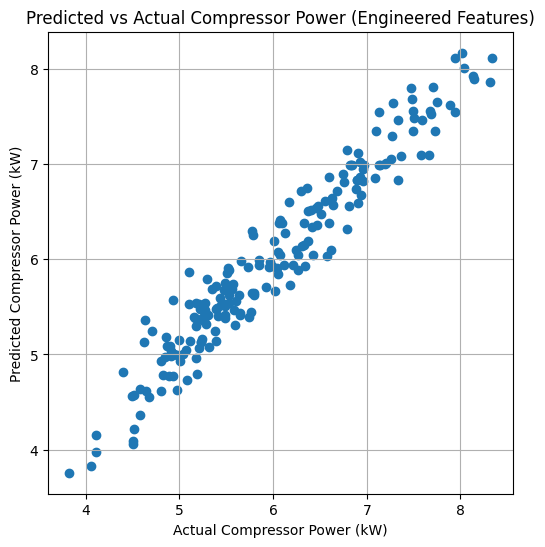

In [7]:
plt.figure(figsize=(6, 6))
plt.scatter(y, y_pred_eng)
plt.xlabel("Actual Compressor Power (kW)")
plt.ylabel("Predicted Compressor Power (kW)")
plt.title("Predicted vs Actual Compressor Power (Engineered Features)")
plt.grid(True)
plt.show()

# 10. Coefficient Interpretation

One advantage of linear regression is that we can inspect the learned coefficients.

These coefficients tell us how strongly each feature influences the predicted compressor power.

In [8]:
coef_df = pd.DataFrame({
    "Feature": engineered_features,
    "Coefficient": model_eng.coef_
})

coef_df

,Feature,Coefficient
0,AmbientTemp_C,0.052759
1,TempError,0.117168
2,SolarScaled,1.498855
3,HumidityScaled,1.356582
4,BlowerSpeed,0.078440


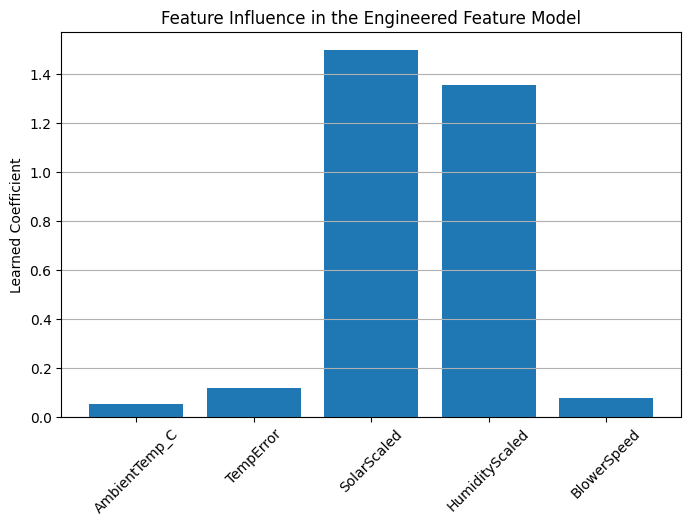

In [9]:
plt.figure(figsize=(8, 5))
plt.bar(coef_df["Feature"], coef_df["Coefficient"])
plt.xticks(rotation=45)
plt.ylabel("Learned Coefficient")
plt.title("Feature Influence in the Engineered Feature Model")
plt.grid(True, axis="y")
plt.show()

Note:

Feature scaling affects the magnitude of model coefficients.  
A large coefficient does not necessarily mean a variable is more important physically.

To compare feature importance fairly, features are often standardized or normalized before training.

# Engineering Interpretation

The learned coefficients reflect the synthetic relationship used to generate the dataset.

In this example:

• SolarScaled has the largest influence because solar load was scaled by dividing by 1000, which increases the numerical weight of the coefficient.

• HumidityScaled also appears large because humidity was scaled by dividing by 100.

• TempError represents the cabin cooling demand. A larger temperature error increases compressor power.

• Ambient temperature has a smaller but noticeable effect on compressor power.

• Blower speed has a modest influence because it slightly increases the cooling demand seen by the HVAC system.

It is important to note that coefficient magnitude depends on the **scale of the feature**, not just the physical importance of the variable.

# 12. Key Takeaways

- Feature engineering means creating better input variables from raw measurements
- Simple engineered variables such as temperature differences can be very powerful
- Good features often improve model interpretability
- Domain knowledge is extremely valuable in machine learning
- In engineering systems, meaningful simple features often matter more than complicated algorithms

# 13. Try It Yourself

Try the following experiments:

1. Add a new engineered feature such as:
   - `CoolingIndex = TempError * SolarScaled`

2. Remove humidity and compare the results

3. Add a synthetic thermal-mass-related feature

4. Compare coefficient interpretations between raw and engineered models

These small changes help build intuition for how feature selection shapes model behavior.